**Task1: Using the Iris dataset, complete the following tasks:**

1. **Train SVM with different kernel functions (linear, rbf, poly).**
2. **Visualize the decision boundaries in 2D (using only the first two features).**
3. **Print the classification report.**
4. **Use GridSearchCV to automatically tune hyperparameters and find the optimal parameters.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
# 🎯 Step 1: Load the dataset and select the first two features for visualization
iris = datasets.load_iris()
X = iris.data[:, :2]  # Only use the first two features
y = iris.target

# 🎯 Step 2: Preprocessing - split into training and test sets, then standardize
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# 🎯 Step 3: Train SVM models using different kernel functions and compare their performance
kernels = ['linear', 'rbf', 'poly']
models = {}

for kernel in kernels:
     # TODO: Initialize the SVC model with the specified kernel and fit the training data
    # clf = ...

    # TODO: Fit the model
    # clf.fit(...)

    # TODO: Predict on the test set
    # y_pred = clf.predict(...)

    # TODO: Print accuracy and classification report
    # print("Accuracy:", ...)
    # print(classification_report(...))

    # TODO: Store the trained model in the models dictionary
    # models[kernel] = clf


SVM with kernel = 'linear'
Accuracy: 0.7333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45


SVM with kernel = 'rbf'
Accuracy: 0.7333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45


SVM with kernel = 'poly'
Accuracy: 0.7555555555555555
Classification Report:
   

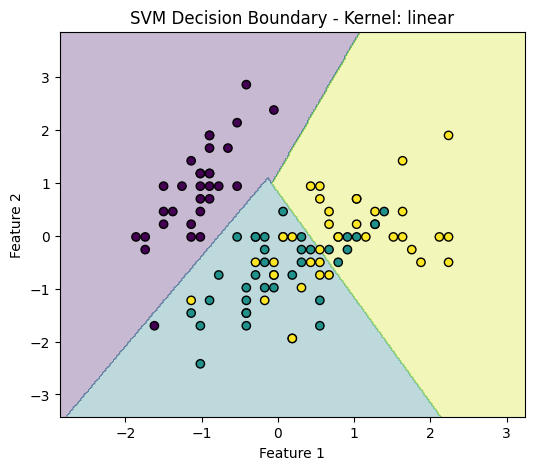

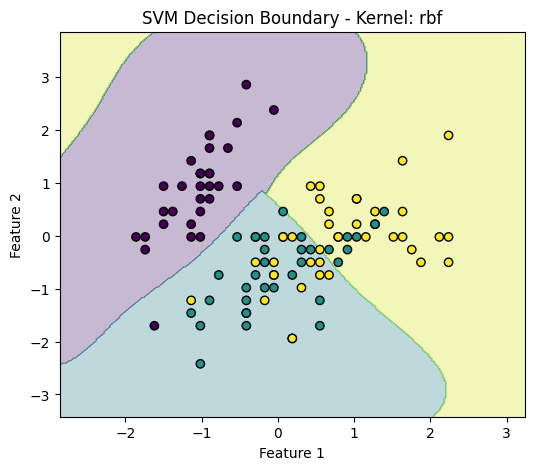

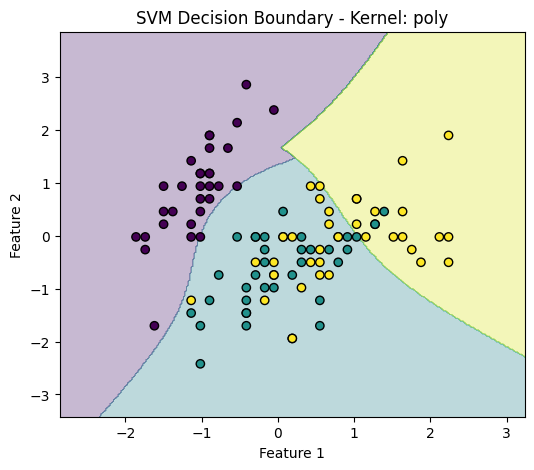

In [5]:
# 🎯 Step 4: Define a function to plot the decision boundaries
# TO DO : Define a function to plot the decision boundaries 

# 显示每个核函数的决策边界
for kernel in kernels:
    plot_decision_boundary(models[kernel], X_train, y_train, f"SVM Decision Boundary - Kernel: {kernel}")

In [6]:
# 🎯 Step 6: Use GridSearchCV for hyperparameter tuning (RBF kernel)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale', 'auto']
}
# TODO: Initialize and run GridSearchCV
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# TODO: Print the best parameters
# print(grid_search.best_params_)

# TODO: Evaluate the best model on the test set
# y_pred_best = ...
# print(classification_report(...))


🔍 Performing GridSearchCV on RBF kernel...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best parameters from GridSearchCV:
{'C': 0.1, 'gamma': 'scale'}

Classification Report (Best RBF Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.64      0.54      0.58        13
           2       0.60      0.69      0.64        13

    accuracy                           0.78        45
   macro avg       0.75      0.74      0.74        45
weighted avg       0.78      0.78      0.78        45



**Task 2: Implementing a Linear SVM from Scratch (without using sklearn):**

1. **How to Build a Linear Classifier from Scratch**
2. **Comparison with sklearn Implementation**

### 🧠 Linear SVM: Primal Optimization Objective

We aim to minimize the following cost function:

$$
\min_{w, b} \quad \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \max\left(0,\; 1 - y_i (w^T x_i + b)\right)
$$

---

- The first term is the **regularization term**:
  
  $$
  \frac{1}{2} \|w\|^2
  $$

  This term penalizes large weights and helps to maximize the margin.

- The second term is the **Hinge Loss** over all training samples:

  $$
  \max(0,\; 1 - y_i f(x_i)) = \max\left(0,\; 1 - y_i (w^T x_i + b)\right)
  $$

  This loss is **non-zero only if** a sample is misclassified or lies within the margin boundary.

---

- \( C \) is the **regularization parameter**:  
  It controls the trade-off between achieving a low error on the training data and having a large margin.



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# 🎯 Step 1: Generate linearly separable 2-class data
X, y = make_blobs(n_samples=400, centers=2, random_state=12, cluster_std=1.2)
y = np.where(y == 0, -1, 1)   # Convert labels from 0/1 to -1/+1 for SVM

scaler = StandardScaler()
X = scaler.fit_transform(X)

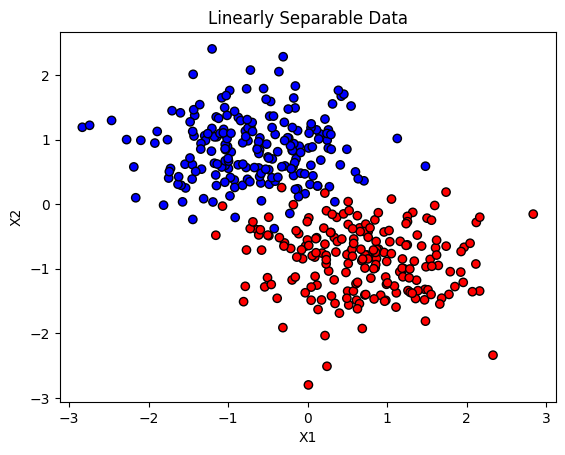

In [1]:
# 🎯 Step 2: Visualize the data
#TO DO Visualize the data


In [9]:
# 🎯 Step 3: Implement Linear SVM from scratch 
class MyLinearSVM:
    def __init__(self, learning_rate=0.01, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param  # 正则项系数
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, xi in enumerate(X):
                # TODO: Compute the margin condition
                # condition = ...

                if condition:
                   # TODO: Compute gradient when condition is satisfied
                    # dw = ...
                    # db = ...
                else:
                    # TODO: Compute gradient when condition is violated
                    # dw = ...
                    # db = ...
                # TODO: Update weights and bias
                # self.w -= ...
                # self.b -= ...

    def predict(self, X):
        # TODO: Return prediction based on sign of linear output
        # linear_output = ...
        # return ...

In [3]:
# 🎯 Step 4: Train and evaluate your custom SVM
svm = MyLinearSVM()
svm.fit(X, y)
preds = svm.predict(X)

print("\n📊 Accuracy (Custom SVM):", accuracy_score(y, preds))


📊 Accuracy (Custom SVM): 0.98


In [4]:
# 🎯 Step 5: Compare with sklearn's LinearSVC
clf = LinearSVC(C=1e10, max_iter=1000)
clf.fit(X, y)
sk_preds = clf.predict(X)

print("📊 Accuracy (sklearn LinearSVC):", accuracy_score(y, sk_preds))

📊 Accuracy (sklearn LinearSVC): 0.9775



📊 Accuracy (Custom SVM): 0.98
📊 Accuracy (sklearn LinearSVC): 0.9775


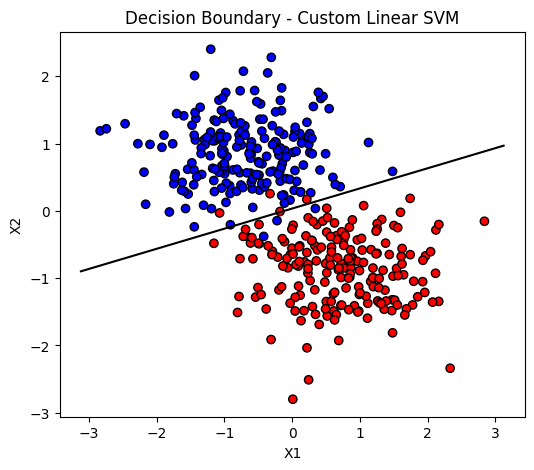

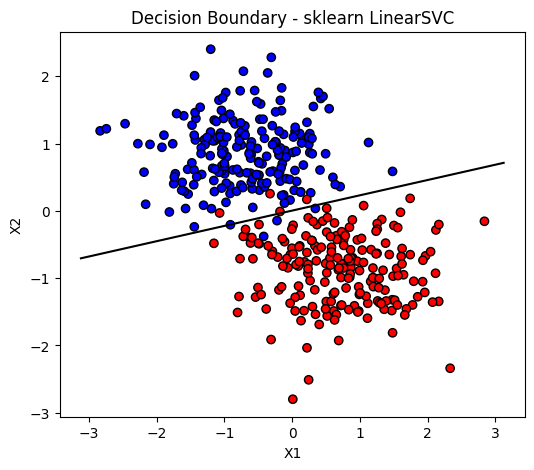

In [2]:
# 🎯 Step 6: Visualize decision boundaries
#TO DO： decision boundaries
def plot_boundary(model, X, y, title, use_sklearn=False):
 

# 自定义模型决策边界
plot_boundary(svm, X, y, "Decision Boundary - Custom Linear SVM")

# sklearn 模型决策边界
plot_boundary(clf, X, y, "Decision Boundary - sklearn LinearSVC", use_sklearn=True)